In [1]:
N_FILTERS = 256     # Frequency bins (try 128, 256, 512)
FRMLEN_MS = 4.0       # Frame length in ms

RIPPLE_F_MIN = 1000 / (2 ** (5.3 / 2))  # ≈ 158 Hz
RIPPLE_OCTAVES = 5.3

In [2]:
import sys

sys.path.insert(0, "..")

import re
from pathlib import Path
import librosa
import pygaborstm as stm

config = stm.Config(
    resolution="low",
    n_filters=N_FILTERS,
    frmlen_ms=FRMLEN_MS,
    f_min=RIPPLE_F_MIN,
    octaves=RIPPLE_OCTAVES,
)
model = stm.PyGaborSTM(config)

print(f"PyGaborSTM version: {stm.__version__}")

# Config
DATA_DIR = Path("./data")
RIPPLE_DIR = DATA_DIR / "mvripfft"
SR = 16000
DURATION = 5.0

print(f"RIPPLE_DIR: {RIPPLE_DIR.resolve()}")

/root/.cache/pypoetry/virtualenvs/pygaborstm-bmo-O-D_-py3.12/lib/python3.12/site-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


PyGaborSTM version: 0.1.0
RIPPLE_DIR: /root/JHU-LCAP/PyGaborSTM/data/mvripfft


In [3]:
def load_audio(filepath):
    """Load audio snippet."""
    audio, _ = librosa.load(filepath, sr=SR)
    max_samples = int(DURATION * SR)
    return audio[:max_samples] if len(audio) > max_samples else audio


def parse_ripple_filename(filename):
    """Extract rate and scale from filename like 'ripple_R-32.00_S0.25.wav'"""
    match = re.search(r'R(-?\d+\.?\d*)_S(\d+\.?\d*)', filename.stem)
    rate = float(match.group(1))
    scale = float(match.group(2))
    return rate, scale

In [4]:
ripple_files = sorted(RIPPLE_DIR.glob("ripple_*.wav"))
print(f"Found {len(ripple_files)} ripple files")

# Get rates/scales from model config
valid_rates = set(model.config.rates)
valid_scales = set(model.config.scales)

# Build data lists
spec_data = []
rsf_data = []
rsf_dict = {}

for filepath in ripple_files:
    rate, scale = parse_ripple_filename(filepath)
    
    # Skip if not in our config
    if rate not in valid_rates or scale not in valid_scales:
        continue
    
    title = f"R{rate:.0f}, S{scale:.2f}"

    # Load and compute
    audio = load_audio(filepath)
    spec = model.spectrogram(audio)
    rsf = model.rsf(spec)

    spec_data.append({"spectrogram": spec, "title": title, "rate": rate, "scale": scale})
    rsf_data.append({"rsf": rsf, "title": title, "rate": rate, "scale": scale})
    rsf_dict[(rate, scale)] = rsf

# Sort by rate (abs value), then scale
spec_data = sorted(spec_data, key=lambda x: (abs(x["rate"]), x["rate"] < 0, x["scale"]))
rsf_data = sorted(rsf_data, key=lambda x: (abs(x["rate"]), x["rate"] < 0, x["scale"]))

print(f"Processed {len(rsf_data)} ripples")

Found 96 ripple files
Processed 60 ripples


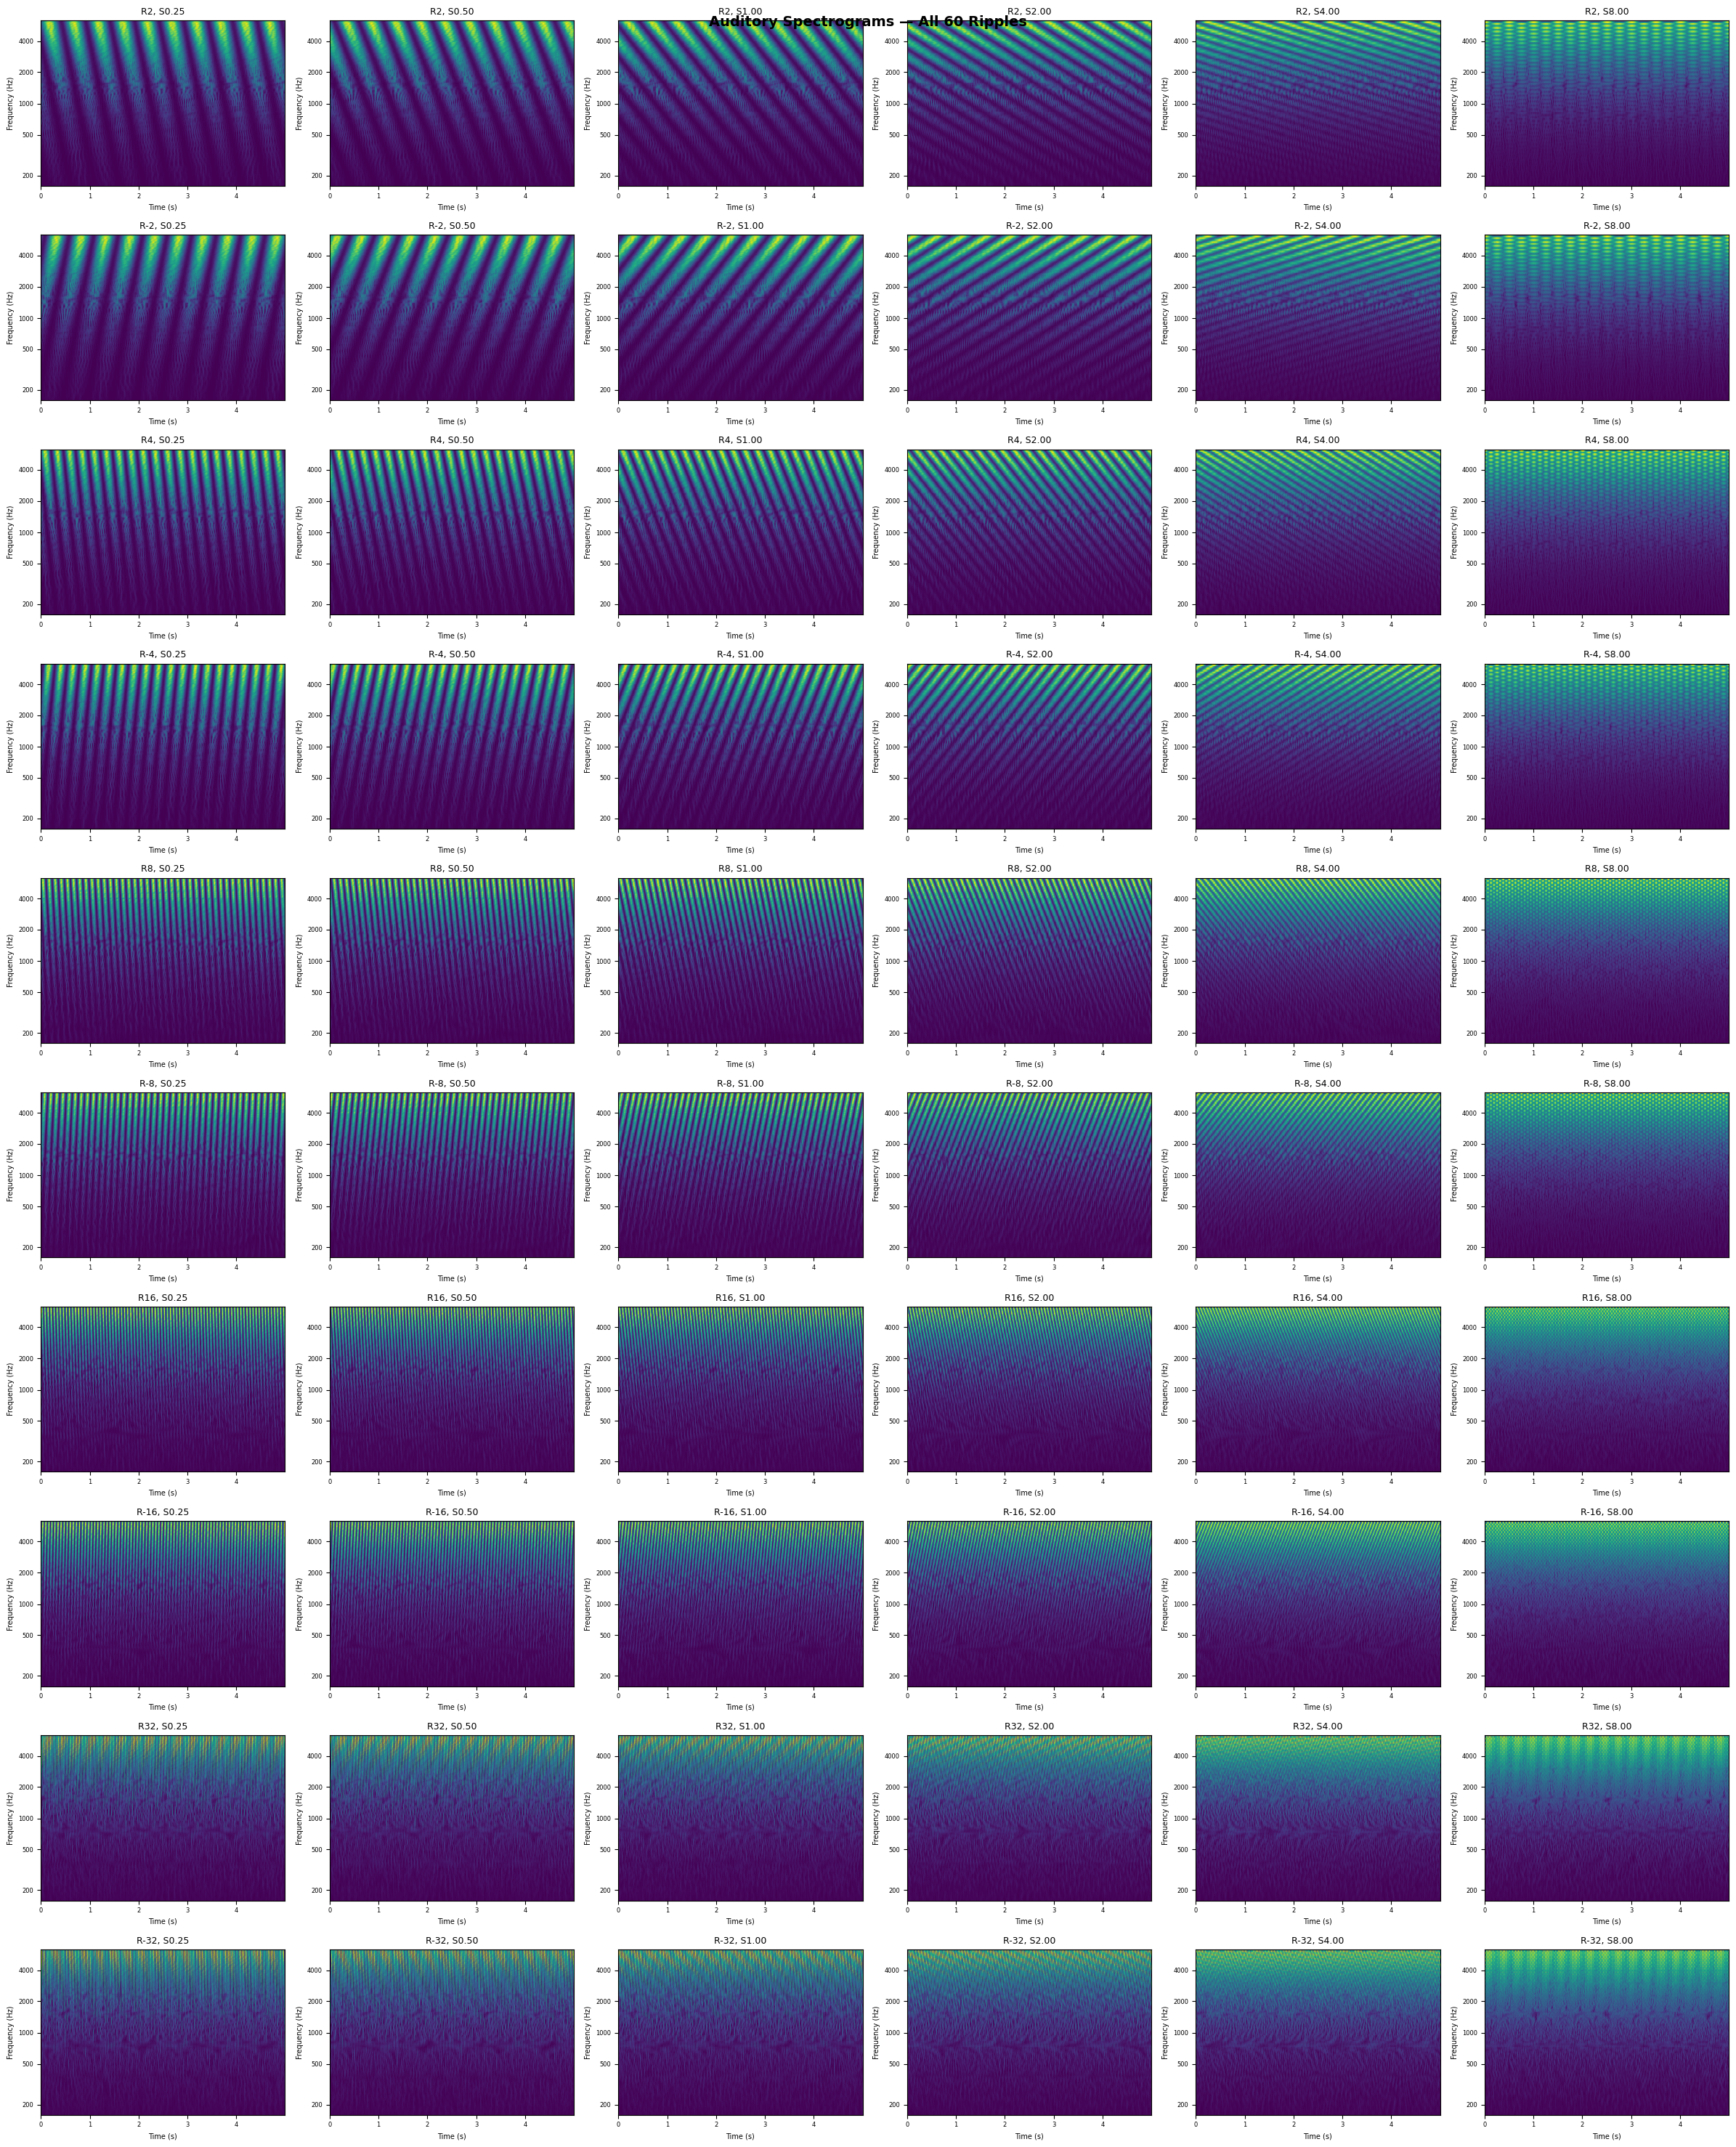

In [5]:
# Plot Spectrograms (10 rates × 6 scales)
stm.plot.plt_spectrogram_grid(
    spec_data,
    n_cols=6,
    suptitle="Auditory Spectrograms — All 60 Ripples",
)

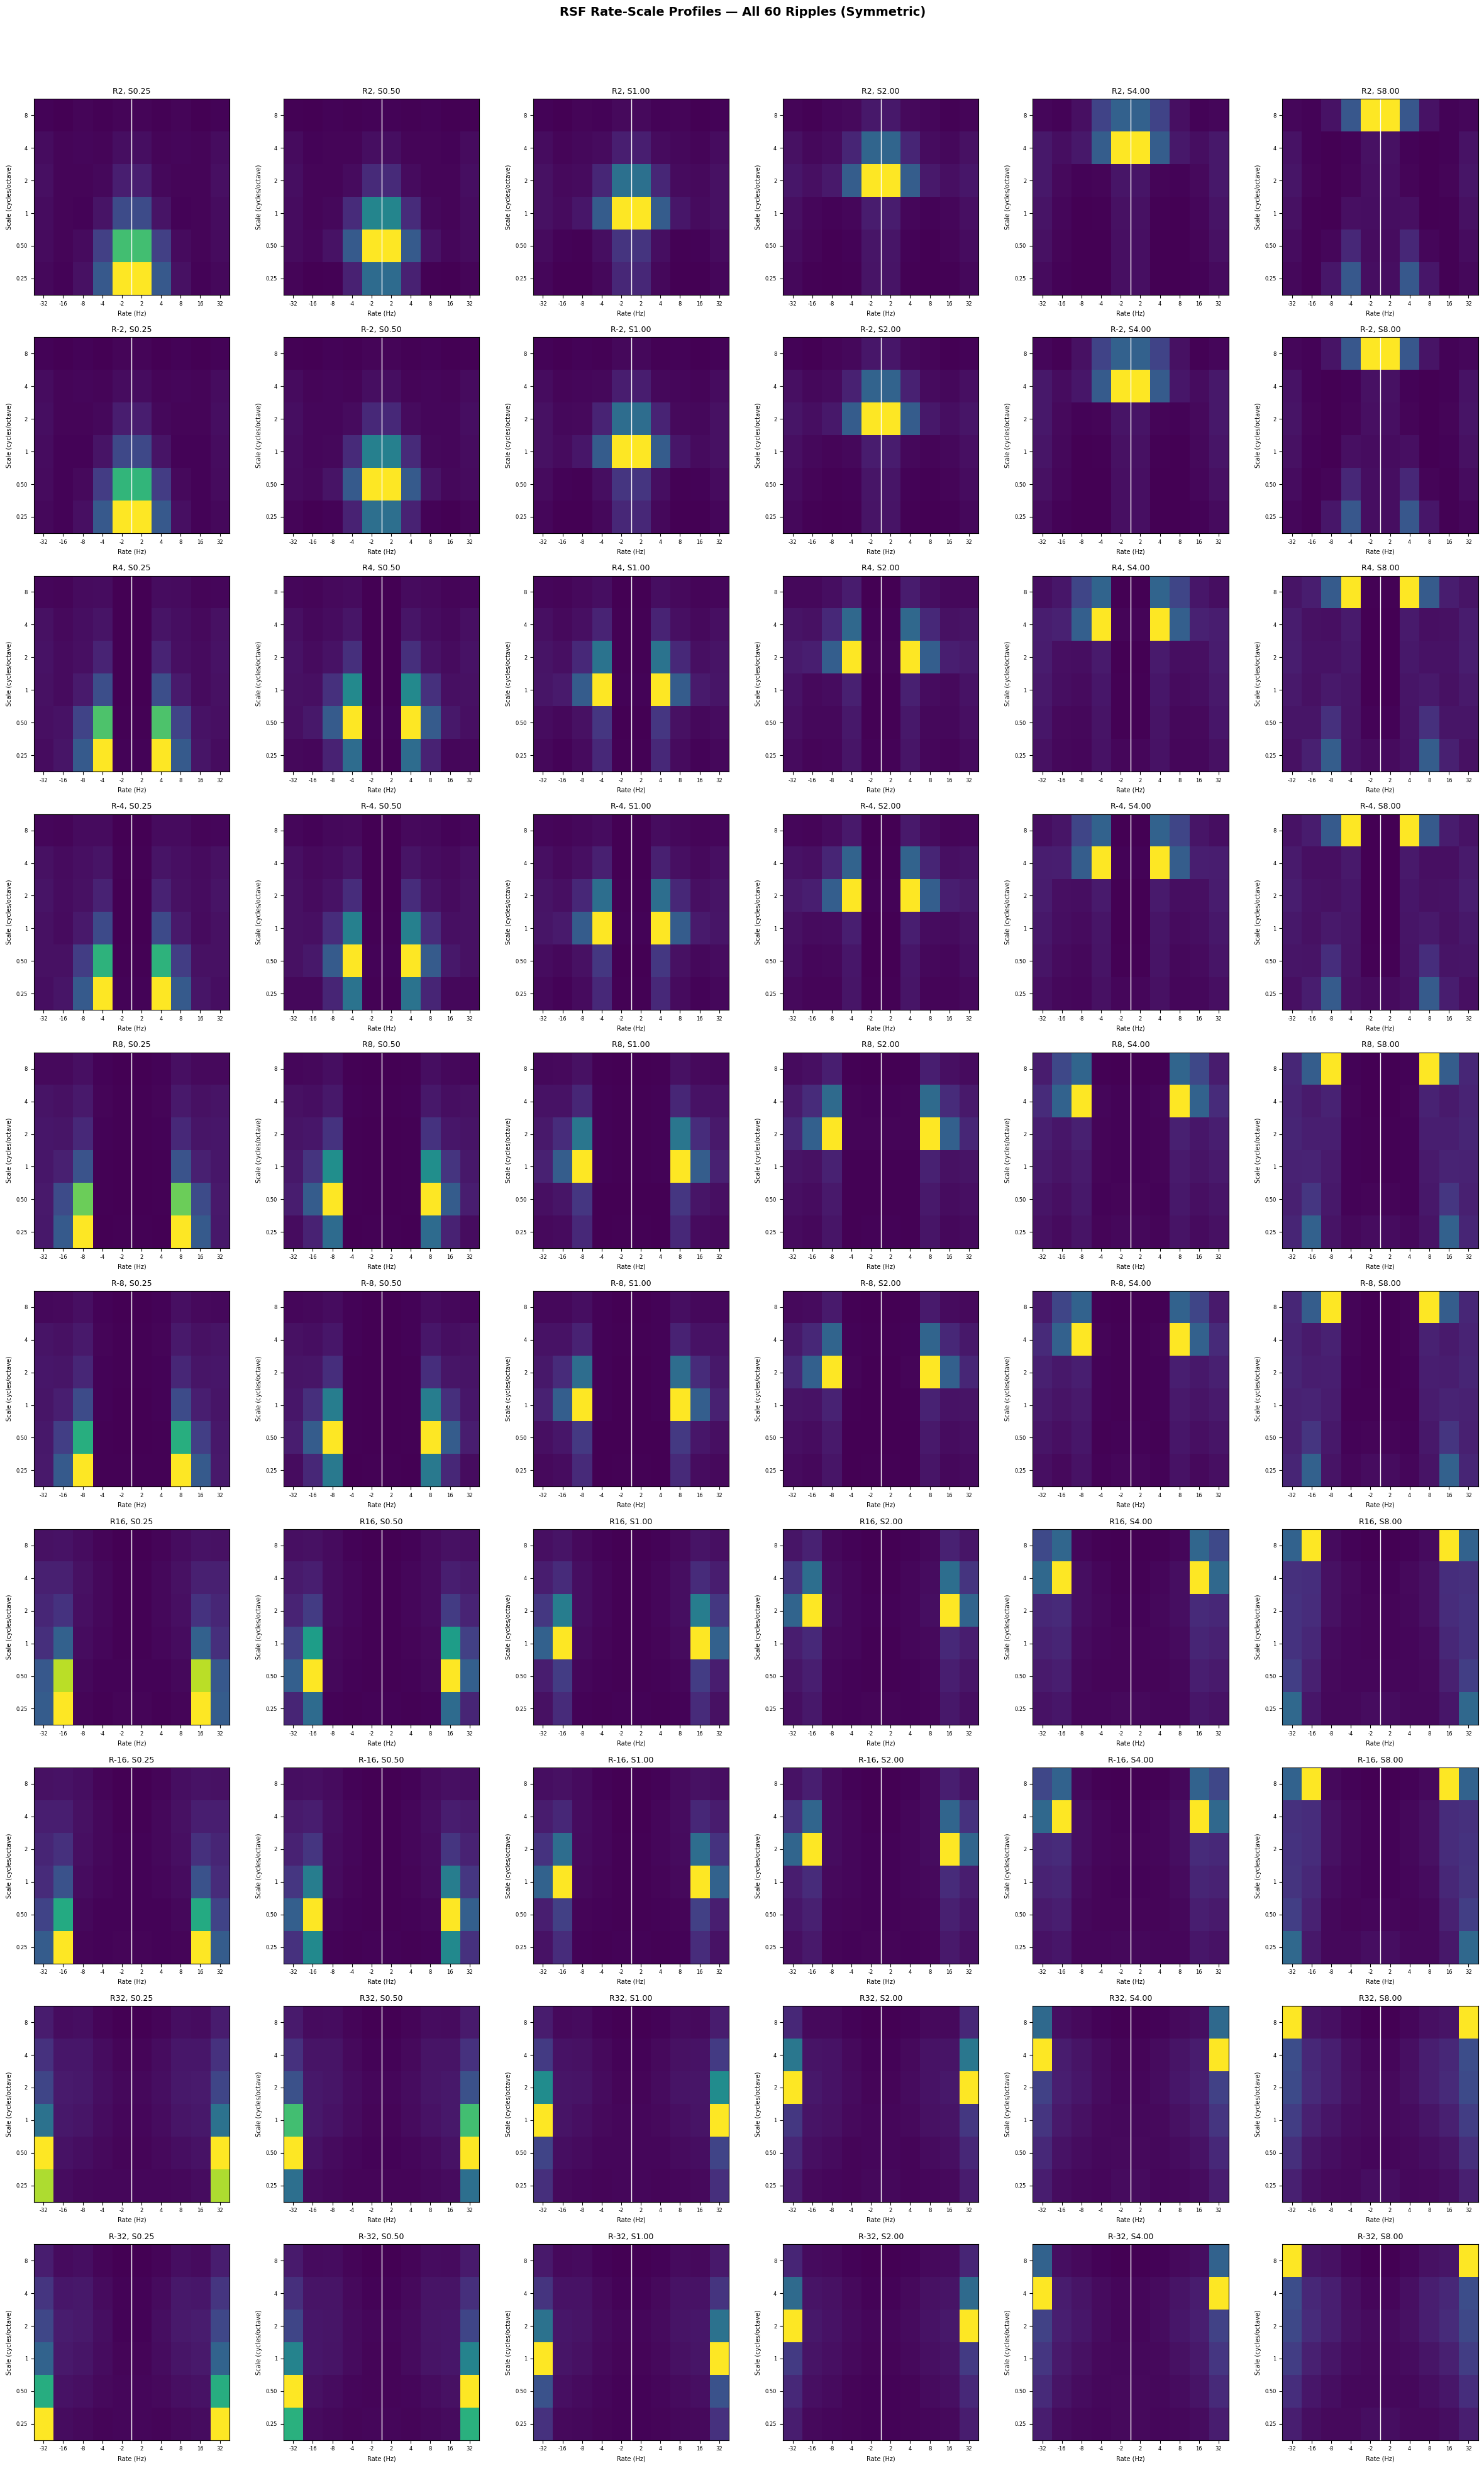

In [6]:
# Plot RSFs (10 rates × 6 scales)
stm.plot.plt_rsf_grid(
    rsf_data,
    n_cols=6,
    fold=True,
    suptitle="RSF Rate-Scale Profiles — All 60 Ripples (Symmetric)",
)

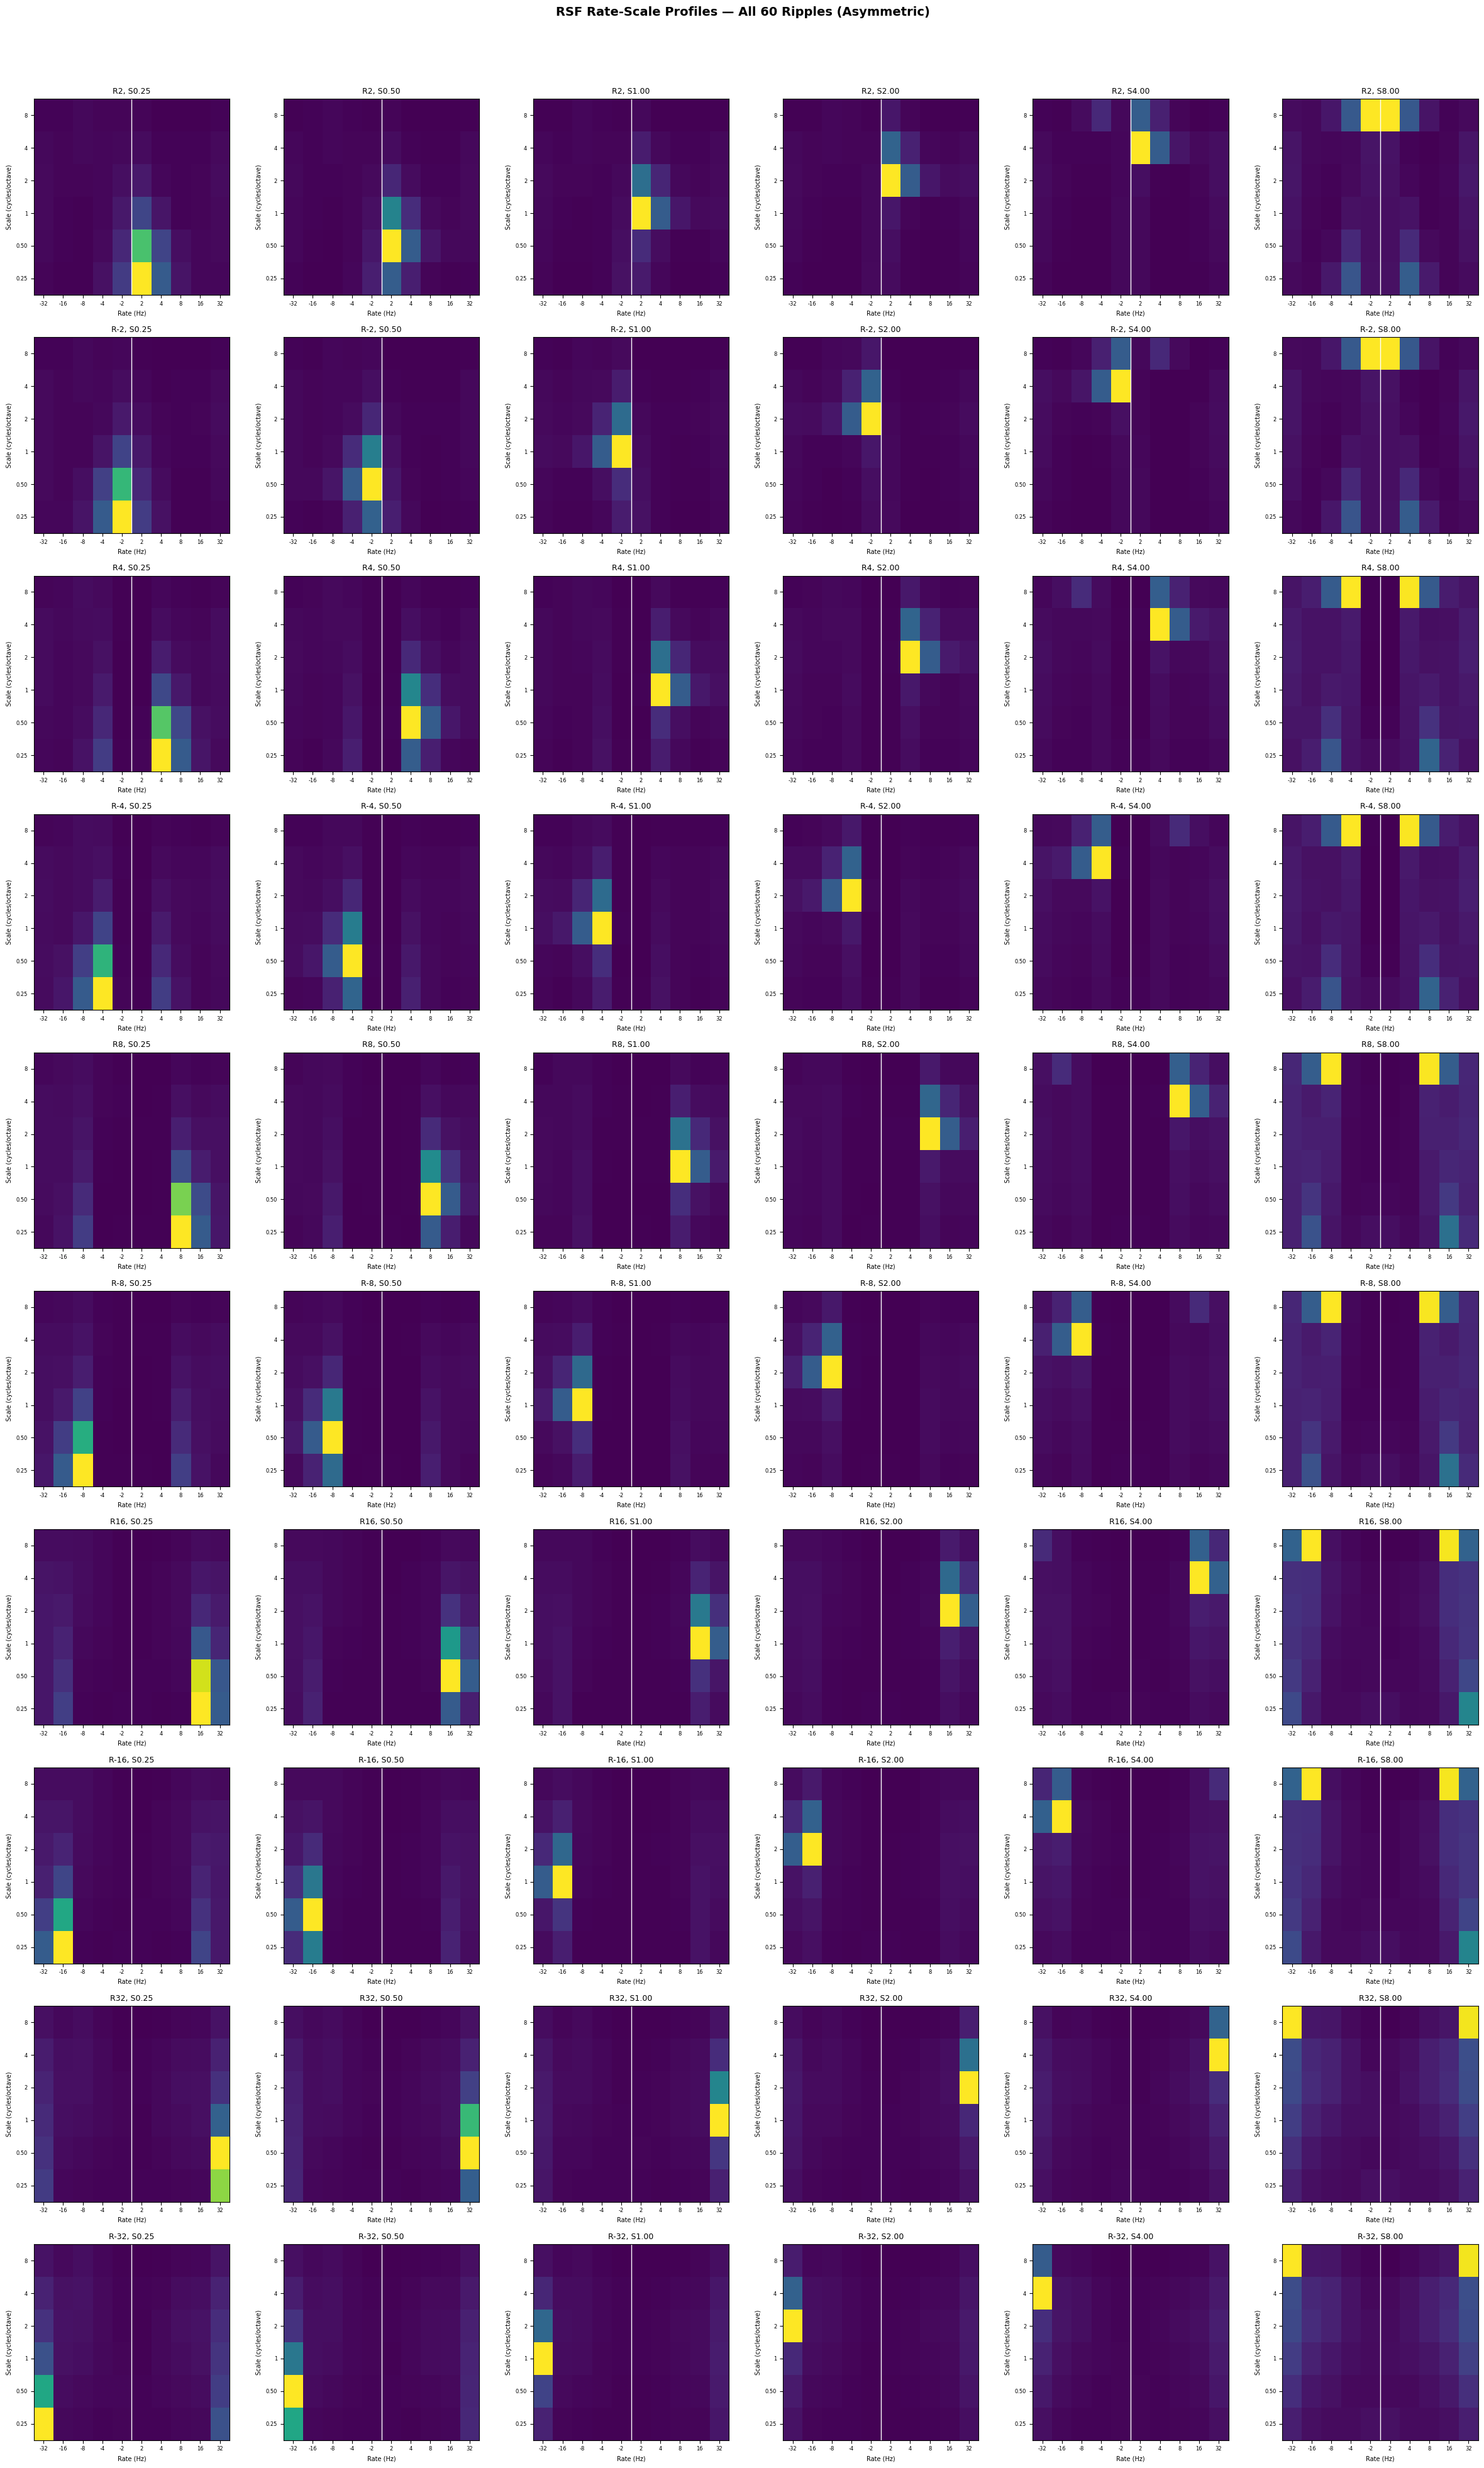

In [7]:
# Plot RSFs (10 rates × 6 scales)
stm.plot.plt_rsf_grid(
    rsf_data,
    n_cols=6,
    fold=False,
    suptitle="RSF Rate-Scale Profiles — All 60 Ripples (Asymmetric)",
)